In [4]:
# Use ! for shell commands in Colab
!pip install tensorflow
!pip install keras


In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


In [6]:
#Load the MNIST dataset
(train_images, train_labels),(test_images,test_labels) = datasets.mnist.load_data()

#Preprocessing :Normalize the pixel value to be btwn 0 and 1
train_images = train_images/ 255.0
test_images = test_images/ 255.0

#reshape the images to (28, 28,1) as they are grayscale

train_images= train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images= test_images.reshape((test_images.shape[0], 28, 28, 1))

In [7]:
#Convert the  labels  to one hot encoder formatting

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)



In [8]:
#Build the cnn model
model =models.Sequential()


# First Convolutional Layer
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

# Second Convolutional Layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Third Convolutional layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Flatten the 3D output to 1D and add a Dense layer
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))

# Output layer with 10 neurons (for 10 digit classes)
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=["accuracy"])

#train the model
model.fit(train_images,train_labels,epochs=5,batch_size=64,validation_data=(test_images,test_labels))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 59s 61ms/step - accuracy: 0.9409 - loss: 0.1887 - val_accuracy: 0.9812 - val_loss: 0.0590
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 54ms/step - accuracy: 0.9838 - loss: 0.0511 - val_accuracy: 0.9876 - val_loss: 0.0379
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.9889 - loss: 0.0352 - val_accuracy: 0.9907 - val_loss: 0.0289
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.9910 - loss: 0.0281 - val_accuracy: 0.9896 - val_loss: 0.0336
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 86s 57ms/step - accuracy: 0.9924 - loss: 0.0237 - val_accuracy: 0.9894 - val_loss: 0.0336


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9894 - loss: 0.0336
Test accuracy: 98.94%
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step
Prediction for first test image: 7


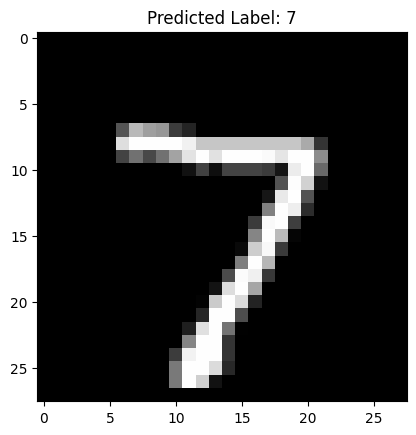

In [9]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc * 100:.2f}%")

# Make predictions on test images
predictions = model.predict(test_images)
print(f"Prediction for first test image: {np.argmax(predictions[0])}")

plt.imshow(test_images[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted Label: {predictions[0].argmax()}")
plt.show()